In [1]:
# Lecture 4
# import packages
from scipy.stats import chi2
import statsmodels.api as sm
from statsmodels.formula.api import glm
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import Probit
from scipy.special import logit, expit
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
# os.chdir(r'C:\Users\Linda\Desktop\ST5213py')
pd.set_option("display.width", 2000)

# import custom functions
from ST5213_helpers import *

# fig_save_dir = r"C:/Users/Linda/OneDrive - National University of Singapore/ST5213 2627/Lectures/Lecture_4/figure"

In [7]:
# Read and preprocess titanic dataset
df = pd.read_csv('dataset/titanic.txt', sep='\t')
print(df.head(),'\n')
print(df.info(),'\n')

# Drop rows with any null values
df = df.dropna()

# drop the variables Name and PClass 
df = df.drop(columns=['Name', 'PClass'])

# Create a numeric variable called Surv with same values as Survived
df['Surv'] = df['Survived']

# Assign Sex and Survived as categorical variables
df['Sex'] = pd.Categorical(df['Sex'])
print(df['Sex'].cat.categories, '\n')
df['Survived'] = pd.Categorical(df['Survived'], categories=[1, 0], ordered=True)

print(df.info())

                                            Name PClass    Age     Sex  Survived
0                   Allen, Miss Elisabeth Walton    1st  29.00  female         1
1                    Allison, Miss Helen Loraine    1st   2.00  female         0
2            Allison, Mr Hudson Joshua Creighton    1st  30.00    male         0
3  Allison, Mrs Hudson JC (Bessie Waldo Daniels)    1st  25.00  female         0
4                  Allison, Master Hudson Trevor    1st   0.92    male         1 

<class 'pandas.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      1313 non-null   str    
 1   PClass    1313 non-null   str    
 2   Age       756 non-null    float64
 3   Sex       1313 non-null   str    
 4   Survived  1313 non-null   int64  
dtypes: float64(1), int64(1), str(3)
memory usage: 51.4 KB
None 

Index(['female', 'male'], dtype='str') 

<class 'pandas.DataFrame'>
Index: 756

In [8]:
#  summary of quantitative variables 
print(df.describe(),'\n')

# count in each category for categorical variable
for j in df.select_dtypes('category'):
    print(df[j].value_counts(),'\n')

              Age        Surv
count  756.000000  756.000000
mean    30.397989    0.414021
std     14.259049    0.492878
min      0.170000    0.000000
25%     21.000000    0.000000
50%     28.000000    0.000000
75%     39.000000    1.000000
max     71.000000    1.000000 

Sex
male      468
female    288
Name: count, dtype: int64 

Survived
0    443
1    313
Name: count, dtype: int64 



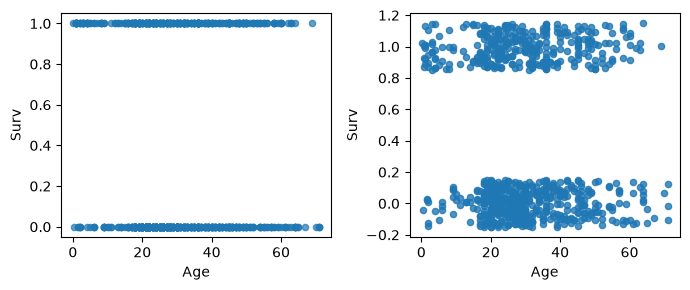

In [9]:
# Visualize relationship bewteen Age, Survived and Sex
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))
df.plot.scatter(x='Age', y='Surv', ax=axes[0], alpha=0.7, s=20)
sns.regplot(data=df, x='Age', y='Surv', y_jitter=0.15, fit_reg=False, ax=axes[1], scatter_kws={'s': 20} )
axes[1].set_ylabel('Surv')
plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "surv_jitter.pdf")
# fig.savefig(fig_path, bbox_inches="tight")  


       Age     Sex Survived  Surv
0     0.17  female        1     1
1     0.33    male        0     0
2     0.80    male        1     1
3     0.83    male        1     1
4     0.83    male        1     1
..     ...     ...      ...   ...
751  69.00  female        1     1
752  70.00    male        0     0
753  71.00    male        0     0
754  71.00    male        0     0
755  71.00    male        0     0

[756 rows x 4 columns]


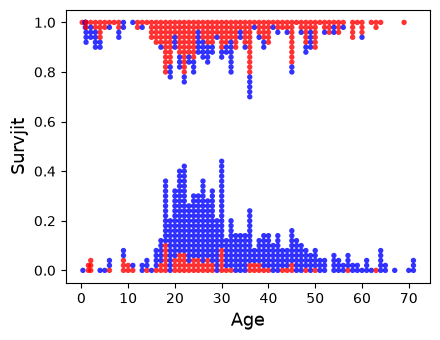

In [10]:
# Sort dataFrame by Age (young to old), and then Sex (female then male) and relabel rows
df = df.sort_values(by=['Age', 'Sex']).reset_index(drop=True)
print(df)

# Create a new variable called Survjit in dataframe
df['Survjit'] = df['Surv'].astype(float)

# create jitter sequence 
jit = df.groupby(['Age', 'Surv']).cumcount() * 0.02

#  Apply jitter to spread overlapping data points upward from 0 or downward from 1
df.loc[df['Surv'] == 0, 'Survjit'] += jit
df.loc[df['Surv'] == 1, 'Survjit'] -= jit

fig, ax = plt.subplots(figsize=(4.5, 3.5))
colors = ['red' if s == 'female' else 'blue' for s in df['Sex']]

ax.scatter(df['Age'], df['Survjit'], c=colors, alpha=0.8, edgecolors='none', s=15)
ax.set_xlabel('Age', fontsize=13)
ax.set_ylabel('Survjit', fontsize=13)

plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "survjit.pdf")
# fig.savefig(fig_path, bbox_inches="tight")  

plt.show()

In [11]:
# Fit GLMs

# probit link
fm_probit = glm('Survived ~ Sex * Age', df, family=Binomial(link=Probit())).fit()
print(fm_probit.summary2(),'\n')

# default logit link
fm_full = glm('Survived ~ Sex * Age', df, family=Binomial()).fit()
print(fm_full.summary2(),'\n')

                     Results: Generalized linear model
Model:              GLM                            Method:         IRLS    
Model Family:       Binomial                       AIC:            779.3629
Link Function:      Probit                         BIC:            797.8751
Dependent Variable: ['Survived[1]', 'Survived[0]'] Log-Likelihood: -385.68 
Date:               2026-09-02 11:28               LL-Null:        -512.79 
No. Observations:   756                            Deviance:       771.36  
Df Model:           3                              Pearson chi2:   764.    
Df Residuals:       752                            Scale:          1.0000  
-----------------------------------------------------------------------------
                     Coef.    Std.Err.      z      P>|z|     [0.025    0.975]
-----------------------------------------------------------------------------
Intercept            0.1991     0.1784    1.1162   0.2643   -0.1505    0.5488
Sex[T.male]         -0.44

In [12]:
# Design matrix
print(fm_full.model.exog , '\n')

# coefficients 
print(fm_full.params, '\n')

# standard error
print(fm_full.bse, '\n')

# Log-likelihood
print(fm_full.llf, '\n') 

# AIC
print(fm_full.aic, '\n') 

# Deviance 
print(fm_full.deviance, '\n') 

# df
print(fm_full.df_resid, '\n') 

# deviance of null model
print(fm_full.null_deviance, '\n') 

[[ 1.    0.    0.17  0.  ]
 [ 1.    1.    0.33  0.33]
 [ 1.    1.    0.8   0.8 ]
 ...
 [ 1.    1.   71.   71.  ]
 [ 1.    1.   71.   71.  ]
 [ 1.    1.   71.   71.  ]] 

Intercept          0.301109
Sex[T.male]       -0.599858
Age                0.029351
Sex[T.male]:Age   -0.065718
dtype: float64 

Intercept          0.298978
Sex[T.male]        0.408050
Age                0.010075
Sex[T.male]:Age    0.013686
dtype: float64 

-385.2777838016901 

778.5555676033802 

770.5555676033802 

752 

1025.5725472453275 



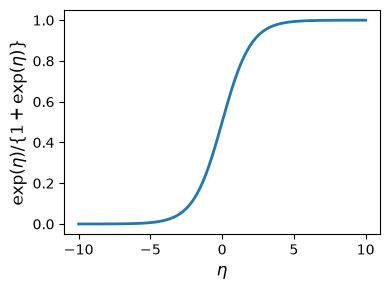

In [16]:
# plot expit (inverse of logit) function 

eta = np.linspace(-10, 10, 100)

# enable LaTex in plot labels
plt.rcParams.update({"text.usetex": False})

plt.figure(figsize=(4, 3))
plt.plot(eta, expit(eta), lw=2)
plt.xlabel(r"$\eta$", fontsize=12) 
plt.ylabel(r"$\exp(\eta)/\{1 + \exp(\eta)\}$", fontsize=12)
plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "expit.pdf")
# plt.savefig(fig_path, bbox_inches="tight")  

count    756.000000
mean      30.397989
std       14.259049
min        0.170000
25%       21.000000
50%       28.000000
75%       39.000000
max       71.000000
Name: Age, dtype: float64 

False
False 

0   -0.298750
1   -0.335116
2   -0.371483
3   -0.407850
4   -0.444217
dtype: float64 

0    0.425863
1    0.416996
2    0.408183
3    0.399428
4    0.390737
dtype: float64 



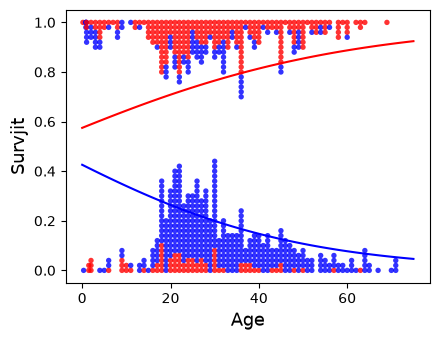

<Figure size 640x480 with 0 Axes>

In [17]:
# compute predictions from fitted GLM 
print(df['Age'].describe(),'\n')         # min: 0.17, max: 71

# Create a grid of all ages from 0 to 75
ages = np.arange(0, 76)

# Build the new dataframes for prediction
pred_m_df = pd.DataFrame({'Age': ages, 'Sex': 'male'})
pred_f_df = pd.DataFrame({'Age': ages, 'Sex': 'female'})

# Compute predicted values on the response scale
pred_m = fm_full.predict(pred_m_df)
pred_f = fm_full.predict(pred_f_df)

# Compute predicted values on the link scale
pred_m_lin = fm_full.predict(pred_m_df, which='linear')
pred_f_lin = fm_full.predict(pred_f_df, which='linear')

# Check
print(expit(pred_m_lin).equals(pred_m))
print(expit(pred_f_lin).equals(pred_f),'\n')

print(pred_m_lin.head(5),'\n')
print(pred_m.head(5),'\n')

ax.plot(ages, pred_m, color="blue")
ax.plot(ages, pred_f, color="red")

plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "pred.pdf")
# fig.savefig(fig_path, bbox_inches="tight")  

from IPython.display import display
display(fig)

In [18]:
print(anova_single(fm_full), '\n')

         Resid. Df   Resid. Dev   Df    Deviance      Pr(>Chi)
NULL         755.0  1025.572547  NaN         NaN           NaN
Sex          754.0   796.643687  1.0  228.928860  1.020805e-51
Age          753.0   795.585535  1.0    1.058152  3.036369e-01
Sex:Age      752.0   770.555568  1.0   25.029967  5.644617e-07 



In [ ]:
# Compute p-value from Chisq-test
print(chi2.sf(228.92886, 1))   # Sex effect
print(chi2.sf(1.058152, 1))    # Age effect
print(chi2.sf(25.029967, 1))   # Sex:Age effect

1.020804738840278e-51
0.30363704959219523
5.64461704234809e-07


In [20]:

# Change order of Sex and Age
fm_fulla = glm('Survived ~ Age * Sex', df, family=Binomial()).fit()
print(anova_single(fm_fulla))

         Resid. Df   Resid. Dev   Df    Deviance      Pr(>Chi)
NULL         755.0  1025.572547  NaN         NaN           NaN
Age          754.0  1022.723218  1.0    2.849329  9.141209e-02
Sex          753.0   795.585535  1.0  227.137684  2.509474e-51
Age:Sex      752.0   770.555568  1.0   25.029967  5.644617e-07


In [21]:
# compare nested models
fm0 = glm('Survived ~ 1', df, family=Binomial()).fit()
fm_age = update_glm(fm0, add='Age')
fm_main = update_glm(fm_age, add='Sex')
print(anova_nested(fm0, fm_age, fm_main, fm_full))

         Resid. Df   Resid. Dev   Df    Deviance      Pr(>Chi)
Model 1      755.0  1025.572547  NaN         NaN           NaN
Model 2      754.0  1022.723218  1.0    2.849329  9.141209e-02
Model 3      753.0   795.585535  1.0  227.137684  2.509474e-51
Model 4      752.0   770.555568  1.0   25.029967  5.644617e-07


In [5]:
n1=12
n2=20
n3=18
theta0=1
s=(2*n1+n2)/theta0-(n2+2*n3)/(2-theta0)
I=(2*n1+n2)/(theta0**2)+(n2+2*n3)/(2-theta0)**2
z=s/np.sqrt(I)
z
from scipy.stats import norm
print(2*(1-norm.cdf(abs(z))))
print(chi2.sf(z**2, 1))

2*n1+n2, n2+2*n3
chi2.ppf(0.95, df=1)

from scipy.stats import chi2
from scipy.optimize import brentq

n1, n2, n3 = 12, 20, 18
n = n1 + n2 + n3

critical = chi2.ppf(0.95, df=1)

def score_stat(theta):
    U = (2*n1 + n2)/theta - (n2 + 2*n3)/(2-theta)
    I = (2*n1 + n2)/theta**2 + (n2 + 2*n3)/(2-theta)**2
    return U**2 / I

def equation(theta):
    return score_stat(theta) - critical

theta_hat = (2*n1 + n2) / n

lower = brentq(equation, 1e-8, theta_hat)
upper = brentq(equation, theta_hat, 2-1e-8)

print(theta_hat)
print(lower, upper)



0.23013934044341644
0.23013934044341317
0.88
0.6815712916424054 1.0784287083575945


In [22]:
n=31
y=1*6+2*2+3*1+4*2+8*1+11*1
p=1/(1+y/n)
p
def ll(p, n, y):

    return n*np.log(p) + y*np.log(1-p)

z=2*(ll(p, n, y) - ll(1/2, n, y))
z

np.float64(1.143920106839417)

In [23]:
print(chi2.sf(z, 1))

0.28482551053289434


In [ ]:
# Fit the multiple linear regression with an interaction term
bee_df = pd.read_csv('dataset/bee.txt', sep=' ')
bee_df['log_removed'] = logit(bee_df['Removed'])
bee_df['log_duration'] = np.log(bee_df['Duration'])
bee_df['queen'] = (bee_df['Bee'] == 'Queen').astype(int)

pollen_model = glm(
    'log_removed ~ log_duration * queen',
    data=bee_df,
    family=sm.families.Gaussian()
).fit()
print(pollen_model.summary())